In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('seasonal_agriculture_performance_dataset (5).csv')


display(df.head())
df.info()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [2]:

print("Missing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])


df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())


print("Missing values after cleaning:\n", df.isnull().sum().sum())

Missing values before cleaning:
 Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Missing values after cleaning:
 0


,Season,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
0,Kharif,5.628612,46.311192,178914.647555
1,Rabi,5.039435,41.486712,87689.470191
2,Zaid,4.641313,38.886111,-24804.824916


C:\Users\Ashish Kumar\AppData\Local\Temp\ipykernel_28568\4096772073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal_performance, x='Season', y='Profit_INR', palette='viridis')


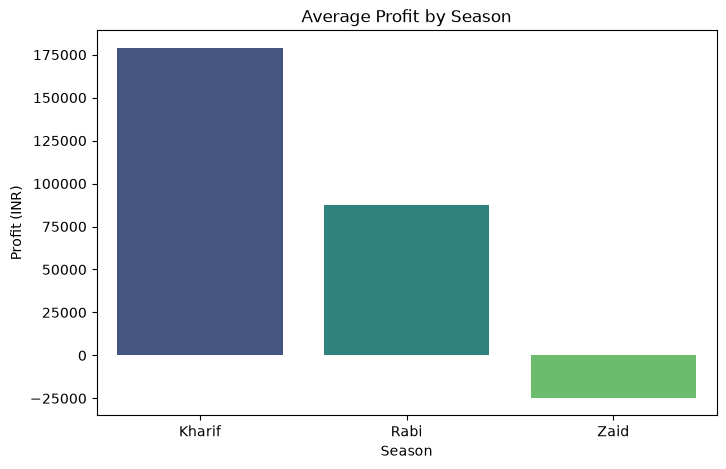

In [3]:

seasonal_performance = df.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']].mean().reset_index()
display(seasonal_performance)

plt.figure(figsize=(8, 5))
sns.barplot(data=seasonal_performance, x='Season', y='Profit_INR', palette='viridis')
plt.title('Average Profit by Season')
plt.ylabel('Profit (INR)')
plt.show() 

,Season,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Fertilizer_kg_ha
0,Kharif,849.199663,28.454019,6102.201237,187.077965
1,Rabi,437.615366,23.489183,5846.987093,185.407068
2,Zaid,304.654714,31.042088,6419.893939,184.638047


C:\Users\Ashish Kumar\AppData\Local\Temp\ipykernel_28568\3054972803.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


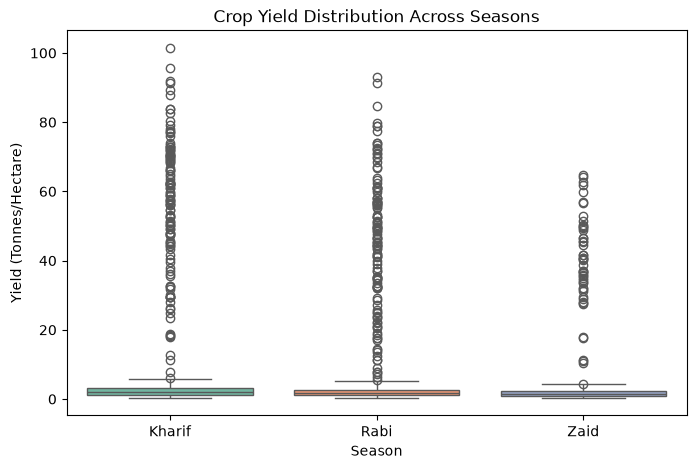

In [4]:

seasonal_env = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Water_Used_m3', 'Fertilizer_kg_ha']].mean().reset_index()
display(seasonal_env)


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Crop Yield Distribution Across Seasons')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.show() 

In [5]:

df.to_csv('cleaned_seasonal_agriculture_data.csv', index=False)
print("Analysis complete. Visualizations are ready for PPT extraction.")

Analysis complete. Visualizations are ready for PPT extraction.
